## make the dataset for training growth rate

In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import glob
import h5py

import sys
sys.path.append('../../../src')
from viz import show_images
from PlumeDataset import plume_dataset
from AutoAlign import align_plumes
from Velocity import VelocityCalculator
from PlumeMetrics import PlumeMetrics

### load growth rate

In [2]:
df_condition = pd.read_excel('../../../../../OneDrive - Drexel University/PLD_SrRuO3/SrRuO3 growth/Sample log.xlsx', 
                             sheet_name='SRO', engine='openpyxl')
df_condition = df_condition.loc[16:33, ['Growth', 'Pressure (mTorr)', 'Fluence (J/cm2)', 'Growth rate (Å/pulse)', 'Pulse number', 'Growth rate (nm/min)']]
df_condition.replace('2 to 1.73', (2+1.73)/2, inplace=True)
df_condition = df_condition.dropna(subset=['Growth rate (Å/pulse)', 'Growth rate (nm/min)'])
df_condition['Growth'] = df_condition['Growth'].str.replace('LYW_YCG', 'YG')
df_condition

,Growth,Pressure (mTorr),Fluence (J/cm2),Growth rate (Å/pulse),Pulse number,Growth rate (nm/min)
16,YG045,75.0,1.692857,0.026700,10000.0,1.60000
17,YG046,75.0,1.865000,0.030875,8000.0,1.80000
18,YG047,75.0,2.050000,0.112000,6000.0,6.70000
22,YG051,75.0,2.050000,0.098033,6000.0,2.94100
24,YG053,75.0,1.600000,0.056600,7000.0,1.69700
27,YG056,100.0,1.600000,0.052600,7000.0,1.57700
28,YG057,75.0,1.230000,0.047286,7000.0,1.41857
29,YG058,125.0,1.600000,0.054000,12000.0,1.62500
30,YG059,50.0,1.600000,0.057600,10000.0,1.72800
31,YG060,75.0,0.800000,0.019000,10000.0,0.57000


### load plumes

In [3]:
growth_names = list(df_condition['Growth'].unique())
print(growth_names)

growth_name_dict = {g: i for i, g in enumerate(growth_names)}
print(growth_name_dict)

['YG045', 'YG046', 'YG047', 'YG051', 'YG053', 'YG056', 'YG057', 'YG058', 'YG059', 'YG060', 'YG061', 'YG062']
{'YG045': 0, 'YG046': 1, 'YG047': 2, 'YG051': 3, 'YG053': 4, 'YG056': 5, 'YG057': 6, 'YG058': 7, 'YG059': 8, 'YG060': 9, 'YG061': 10, 'YG062': 11}


In [4]:
files = []
for key in growth_names:
    files.append(glob.glob(f'../../../datasets/SRO_STO_Drexel/*{key}*.h5')[0])
files

['../../../datasets/SRO_STO_Drexel\\YG045_YichenGuo_JulianGoddy_05092024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG046_YichenGuo_05162024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG047_YichenGuo_05172024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG051_YichenGuo_06122024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG053_YichenGuo_06172024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG056_YichenGuo_06282024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG057_YichenGuo_06282024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG058_YichenGuo_06292024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG059_YichenGuo_07012024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG060_YichenGuo_07032024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG061_YichenGuo_07042024.h5',
 '../../../datasets/SRO_STO_Drexel\\YG062_YichenGuo_07052024.h5']

In [5]:
files_train, files_test = files[:-1], files[-1:]

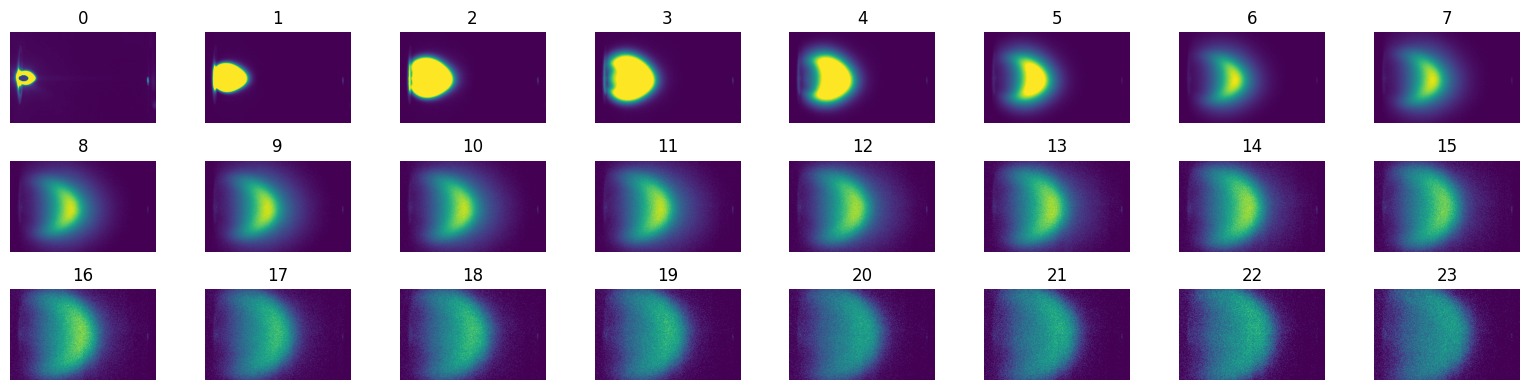

In [6]:
plume_ds = plume_dataset(file_path=files_train[0], group_name='PLD_Plumes')
plumes = plume_ds.load_plumes('1-SrRuO3')[:,:48]
show_images(plumes[0, 2:26], )

In [7]:
length = 0
for file in files_train:
    plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
    keys = plume_ds.dataset_names()
    plumes = plume_ds.load_plumes('1-SrRuO3')
    length += len(plumes)
print(plumes.shape, plumes.dtype, np.min(plumes), np.max(plumes), length)

with h5py.File('../../../datasets/growth_rate_regression_ds_2_26frames_train.h5', 'w') as f:
    f.create_dataset('plumes', shape=(length, 24, 250, 400), dtype=np.uint8)
    f.create_dataset('growth_rate(angstrom_per_pulse)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_rate(nm_per_min)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_name', shape=(length, 1), dtype=np.uint8)

    index = 0
    for growth, file in zip(growth_names, files_train):
        print(file)
        plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
        plumes = plume_ds.load_plumes('1-SrRuO3')[:,2:26]
        f['plumes'][index:index+len(plumes)] = plumes
        print(len(plumes))

        f['growth_rate(angstrom_per_pulse)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (Å/pulse)'].values[0]
        f['growth_rate(nm_per_min)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (nm/min)'].values[0]
        f['growth_name'][index:index+len(plumes)] = growth_name_dict[growth]

        index += len(plumes)

(377, 128, 250, 400) uint8 0 255 2657
../../../datasets/SRO_STO_Drexel\YG045_YichenGuo_JulianGoddy_05092024.h5
156
../../../datasets/SRO_STO_Drexel\YG046_YichenGuo_05162024.h5
125
../../../datasets/SRO_STO_Drexel\YG047_YichenGuo_05172024.h5
94
../../../datasets/SRO_STO_Drexel\YG051_YichenGuo_06122024.h5
189
../../../datasets/SRO_STO_Drexel\YG053_YichenGuo_06172024.h5
219
../../../datasets/SRO_STO_Drexel\YG056_YichenGuo_06282024.h5
219
../../../datasets/SRO_STO_Drexel\YG057_YichenGuo_06282024.h5
282
../../../datasets/SRO_STO_Drexel\YG058_YichenGuo_06292024.h5
376
../../../datasets/SRO_STO_Drexel\YG059_YichenGuo_07012024.h5
314
../../../datasets/SRO_STO_Drexel\YG060_YichenGuo_07032024.h5
306
../../../datasets/SRO_STO_Drexel\YG061_YichenGuo_07042024.h5
377


In [8]:
length = 0
for file in files_test:
    print(file)
    plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
    keys = plume_ds.dataset_names()
    plumes = plume_ds.load_plumes('1-SrRuO3')
    length += len(plumes)
    print(len(plumes))
print(plumes.shape, plumes.dtype, np.min(plumes), np.max(plumes), length)

with h5py.File('../../../datasets/growth_rate_regression_ds_2_26frames_test.h5', 'w') as f:
    f.create_dataset('plumes', shape=(length, 24, 250, 400), dtype=np.uint8)
    f.create_dataset('growth_rate(angstrom_per_pulse)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_rate(nm_per_min)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_name', shape=(length, 1), dtype=np.uint8)

    index = 0
    for growth, file in zip(growth_names, files_test):
        print(file)
        plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
        plumes = plume_ds.load_plumes('1-SrRuO3')[:,2:26]
        f['plumes'][index:index+len(plumes)] = plumes
        print(len(plumes))

        f['growth_rate(angstrom_per_pulse)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (Å/pulse)'].values[0]
        f['growth_rate(nm_per_min)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (nm/min)'].values[0]
        f['growth_name'][index:index+len(plumes)] = growth_name_dict[growth]

        index += len(plumes)

../../../datasets/SRO_STO_Drexel\YG062_YichenGuo_07052024.h5
374
(374, 128, 250, 400) uint8 0 255 374
../../../datasets/SRO_STO_Drexel\YG062_YichenGuo_07052024.h5
374


#### full range

In [ ]:
with h5py.File('../../../datasets/growth_rate_regression_ds.h5', 'w') as f:
    f.create_dataset('plumes', shape=(length, 128, 250, 400), dtype=np.uint8)
    f.create_dataset('growth_rate(angstrom_per_pulse)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_rate(nm_per_min)', shape=(length, 1), dtype=np.float32)
    f.create_dataset('growth_name', shape=(length, 1), dtype=np.uint8)

    index = 0
    for growth, file in zip(growth_names, files):
        print(file)
        plume_ds = plume_dataset(file_path=file, group_name='PLD_Plumes')
        plumes = plume_ds.load_plumes('1-SrRuO3')
        f['plumes'][index:index+len(plumes)] = plumes
        print(len(plumes))

        f['growth_rate(angstrom_per_pulse)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (Å/pulse)'].values[0]
        f['growth_rate(nm_per_min)'][index:index+len(plumes)] = df_condition[df_condition['Growth'] == growth]['Growth rate (nm/min)'].values[0]
        f['growth_name'][index:index+len(plumes)] = growth_name_dict[growth]

        index += len(plumes)